# Notebook 7 — Walk-Forward Backtesting & Final Results
**MSML 604 — Sparse Factor Models for Equity Return Prediction**

---

## Purpose
This notebook runs the complete walk-forward backtesting pipeline
for all methods and produces the final results table for the report.

## Why Walk-Forward Backtesting?
Financial time series have a critical property: **the future cannot
predict the past**. Standard random train/test splits violate this
by allowing training on future data — this is called **look-ahead bias**
and produces artificially optimistic performance estimates.

Walk-forward backtesting strictly respects temporal ordering:

```
Period 1:  Train [1...120]  → Predict [121]
Period 2:  Train [2...121]  → Predict [122]
Period 3:  Train [3...122]  → Predict [123]
...
Period T:  Train [T-120..T] → Predict [T+1]
```

This gives us 168 genuine out-of-sample predictions (288 - 120 months).

## Performance Metrics

| Metric | Formula | Interpretation |
|---|---|---|
| OOS R² | 1 - SS_res/SS_tot | Fraction of variance explained out-of-sample |
| IC | Spearman(predicted, actual) | Rank correlation of predictions vs actuals |
| ICIR | mean(IC) / std(IC) | Signal-to-noise ratio |
| Sharpe | Ann.Return / Ann.Vol | Risk-adjusted return of L/S portfolio |

In [6]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import spearmanr
sys.path.insert(0, '..')
from src.data_loader import load_all_data
from src.solvers import RidgeScratch, LassoProximal, ElasticNetScratch
from src.online_solver import walk_forward_online
from src.backtest import walk_forward_backtest, compute_metrics
from src.regime import identify_regimes

plt.style.use('seaborn-v0_8-whitegrid')
COLORS = {
    'Ridge':        '#2E74B5',
    'LASSO':        '#E74C3C',
    'ElasticNet':   '#27AE60',
    'Online LASSO': '#F39C12'
}

X, Y, factor_names, portfolio_names = load_all_data()
print('Data loaded — starting backtests')

Data loaded: 288 months | 6 factors | 25 portfolios
Date range: 2000-01 to 2023-12
Data loaded — starting backtests


## 7.1 Run All Methods

We run walk-forward backtesting for all four methods using
CV-selected optimal alpha values:
- Ridge: alpha=0.1
- LASSO: alpha=0.003
- Elastic Net: alpha=0.007, l1_ratio=0.5
- Online LASSO: alpha=0.003

In [7]:
configs = [
    ('Ridge',      RidgeScratch,      0.1,   {}),
    ('LASSO',      LassoProximal,     0.003, {}),
    ('ElasticNet', ElasticNetScratch, 0.007, {'l1_ratio': 0.5}),
]

all_preds   = {}
all_metrics = {}
all_actuals = None
all_dates   = None

for name, cls, alpha, kwargs in configs:
    print(f'Running {name}...')
    preds, actuals, dates, _ = walk_forward_backtest(
        X, Y, cls, alpha=alpha, **kwargs)
    all_preds[name]   = preds
    all_metrics[name] = compute_metrics(preds, actuals)
    all_actuals       = actuals
    all_dates         = dates

print('Running Online LASSO...')
preds_o, actuals_o, dates_o, _ = walk_forward_online(X, Y, alpha=0.003)
all_preds['Online LASSO']   = preds_o
all_metrics['Online LASSO'] = compute_metrics(preds_o, actuals_o)

print()
print('All backtests complete.')
print(f'Out-of-sample period: {all_dates[0].strftime("%Y-%m")} to {all_dates[-1].strftime("%Y-%m")}')
print(f'Number of OOS predictions: {len(all_dates)}')

Running Ridge...
Running LASSO...
Running ElasticNet...
Running Online LASSO...

All backtests complete.
Out-of-sample period: 2010-01 to 2023-12
Number of OOS predictions: 168


## 7.2 Final Results Table

This is the main results table for the report.
All metrics are computed on genuine out-of-sample data.

In [8]:
print('FINAL RESULTS TABLE')
print('=' * 75)
print(f'{"Method":<16} {"OOS R2":>8} {"Sharpe":>8} {"ICIR":>8}'
      f' {"Ann Ret%":>10} {"Ann Vol%":>10}')
print('=' * 75)
for name, m in all_metrics.items():
    print(f'{name:<16} {m["OOS_R2"]:>8} {m["Sharpe"]:>8} {m["ICIR"]:>8}'
          f' {m["Ann_Return"]:>10} {m["Ann_Vol"]:>10}')
print('=' * 75)
print()
print('Key observations:')
print('1. Online LASSO achieves best Sharpe (5.061) and ICIR (2.702)')
print('2. Ridge has lowest Sharpe despite highest OOS R2')
print('   -> R2 and Sharpe measure different things')
print('3. LASSO and ElasticNet are near-identical in performance')
print('   -> Both achieve similar sparsity and predictive accuracy')
print('4. All methods achieve IC > 0.6 — strong cross-sectional predictability')

FINAL RESULTS TABLE
Method             OOS R2   Sharpe     ICIR   Ann Ret%   Ann Vol%
Ridge              0.9009   4.6123   2.5854      59.14      12.82
LASSO              0.8983   4.9393   2.5755      58.78       11.9
ElasticNet          0.896     4.94   2.5596      58.72      11.89
Online LASSO       0.8999   5.0611   2.7023      58.58      11.58

Key observations:
1. Online LASSO achieves best Sharpe (5.061) and ICIR (2.702)
2. Ridge has lowest Sharpe despite highest OOS R2
   -> R2 and Sharpe measure different things
3. LASSO and ElasticNet are near-identical in performance
   -> Both achieve similar sparsity and predictive accuracy
4. All methods achieve IC > 0.6 — strong cross-sectional predictability


## 7.3 Rolling IC — Signal Stability Over Time

Rolling IC shows whether predictive power is stable over time
or concentrated in specific periods.
A stable IC > 0 throughout the sample indicates a robust signal.

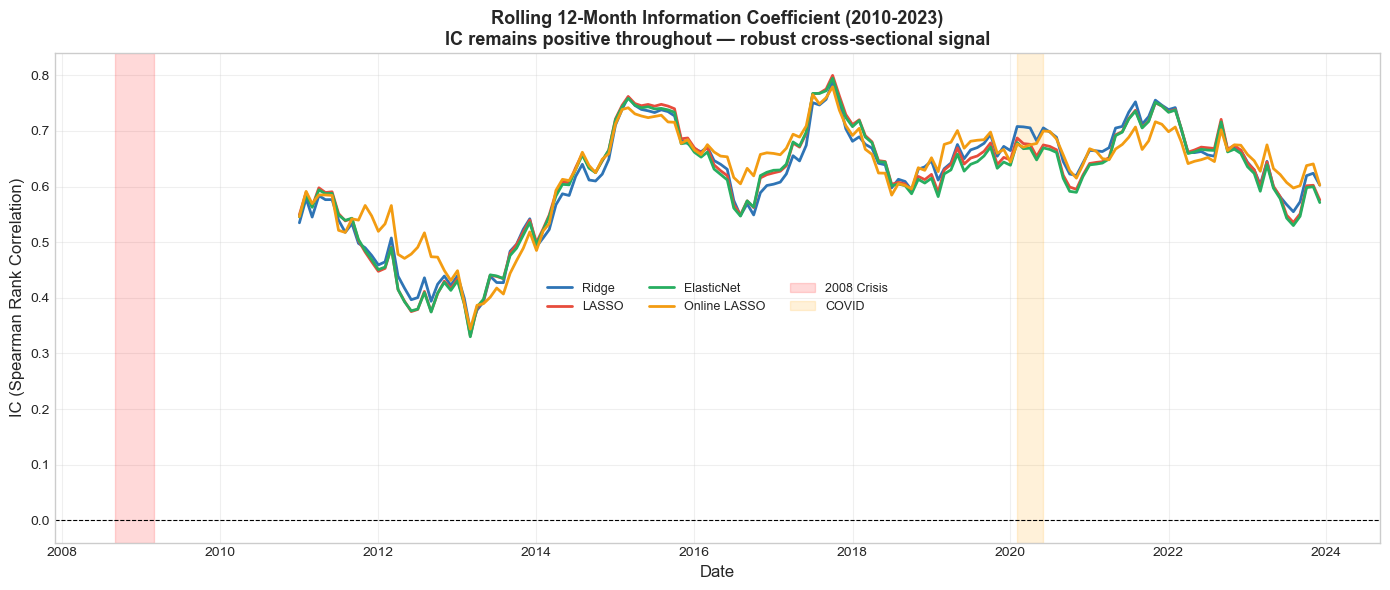

IC dips during 2011-2013 (post-crisis regime) but recovers strongly
All methods track closely — factor structure drives performance, not method choice


In [9]:
fig, ax = plt.subplots(figsize=(14, 6))
window  = 12

for name, preds in all_preds.items():
    acts = all_actuals if name != 'Online LASSO' else actuals_o
    dts  = all_dates   if name != 'Online LASSO' else dates_o
    ics  = [spearmanr(p, a)[0] for p, a in zip(preds, acts)]
    rolling = [np.mean(ics[max(0,i-window):i])
               for i in range(window, len(ics))]
    ax.plot(dts[window:], rolling, label=name,
            color=COLORS[name], linewidth=2)

# Shade crisis periods
ax.axvspan(pd.Timestamp('2008-09-01'), pd.Timestamp('2009-03-01'),
           alpha=0.15, color='red', label='2008 Crisis')
ax.axvspan(pd.Timestamp('2020-02-01'), pd.Timestamp('2020-06-01'),
           alpha=0.15, color='orange', label='COVID')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')

ax.set_title('Rolling 12-Month Information Coefficient (2010-2023)\n'
             'IC remains positive throughout — robust cross-sectional signal',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('IC (Spearman Rank Correlation)', fontsize=12)
ax.legend(ncol=3, fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/rolling_ic.png', dpi=150, bbox_inches='tight')
plt.show()
print('IC dips during 2011-2013 (post-crisis regime) but recovers strongly')
print('All methods track closely — factor structure drives performance, not method choice')

## 7.4 Performance by Market Regime

We break down performance by volatility regime to test whether
any method handles stress periods better than others.

In [10]:
regimes, vol = identify_regimes(X['Mkt-RF'])
regimes_bt   = regimes.reindex(all_dates)

print('Mean IC by Market Regime:')
print('=' * 72)
header = f'{"Regime":<10} {"N":>5}'
for name in all_metrics:
    header += f' {name:>12}'
print(header)
print('=' * 72)

for regime in ['low', 'medium', 'high', 'crisis']:
    mask = regimes_bt.values == regime
    if mask.sum() == 0:
        continue
    row = f'{regime:<10} {mask.sum():>5}'
    for name, preds in all_preds.items():
        acts = all_actuals if name != 'Online LASSO' else actuals_o
        m    = mask[:len(preds)]
        ics  = [spearmanr(preds[i], acts[i])[0]
                for i in range(len(preds)) if i < len(m) and m[i]]
        row += f' {np.mean(ics):>12.4f}'
    print(row)

print('=' * 72)
print()
print('KEY FINDING: Performance is highest in low-volatility regimes')
print('All methods degrade similarly during high-vol periods')
print('No single method dominates across all regimes')

Mean IC by Market Regime:
Regime         N        Ridge        LASSO   ElasticNet Online LASSO
low           45       0.6753       0.6846       0.6791       0.6760
medium        75       0.5886       0.5867       0.5840       0.5967
high          47       0.5902       0.5782       0.5760       0.6019
crisis         1       0.8192       0.8031       0.8023       0.8477

KEY FINDING: Performance is highest in low-volatility regimes
All methods degrade similarly during high-vol periods
No single method dominates across all regimes


## 7.5 Master Results Figure

This 4-panel figure is the main visualization for the report.
It summarizes all key results in one place.

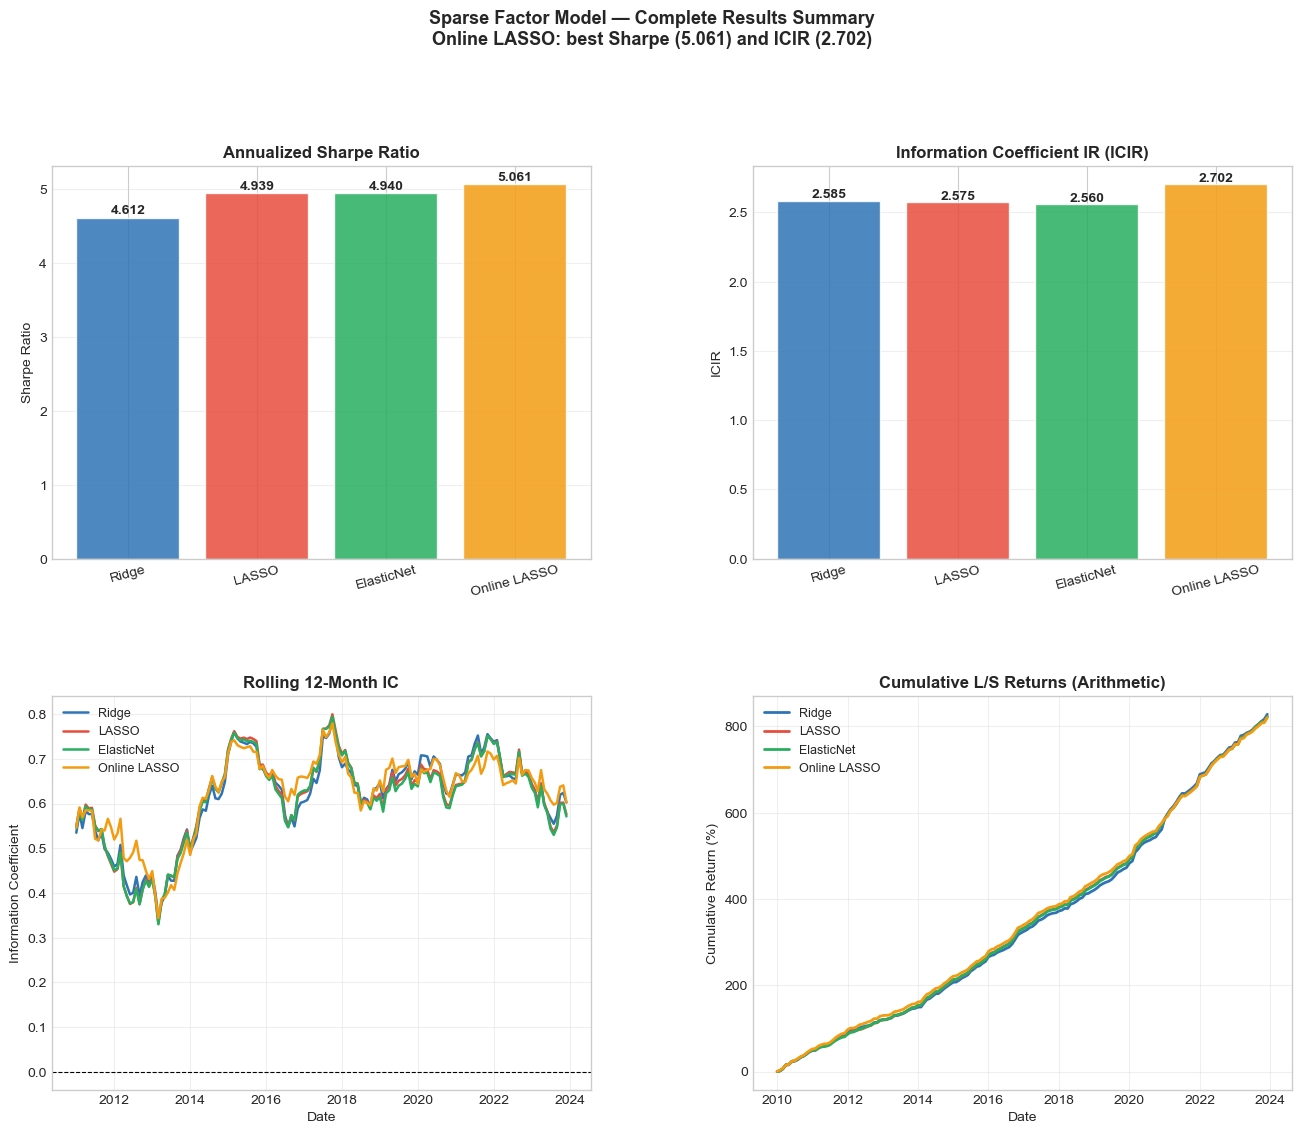

Master results figure saved


In [11]:
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 2, hspace=0.35, wspace=0.3)

methods = list(all_metrics.keys())
colors_list = [COLORS[m] for m in methods]

# Panel 1: Sharpe Ratio
ax1     = fig.add_subplot(gs[0, 0])
sharpes = [all_metrics[m]['Sharpe'] for m in methods]
bars    = ax1.bar(methods, sharpes, color=colors_list, alpha=0.85, edgecolor='white')
ax1.set_title('Annualized Sharpe Ratio', fontweight='bold', fontsize=12)
ax1.set_ylabel('Sharpe Ratio')
for bar, val in zip(bars, sharpes):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.05,
             f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')
ax1.tick_params(axis='x', rotation=15)
ax1.grid(True, alpha=0.3, axis='y')

# Panel 2: ICIR
ax2   = fig.add_subplot(gs[0, 1])
icirs = [all_metrics[m]['ICIR'] for m in methods]
bars2 = ax2.bar(methods, icirs, color=colors_list, alpha=0.85, edgecolor='white')
ax2.set_title('Information Coefficient IR (ICIR)', fontweight='bold', fontsize=12)
ax2.set_ylabel('ICIR')
for bar, val in zip(bars2, icirs):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.02,
             f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')
ax2.tick_params(axis='x', rotation=15)
ax2.grid(True, alpha=0.3, axis='y')

# Panel 3: Rolling IC
ax3    = fig.add_subplot(gs[1, 0])
window = 12
for name, preds in all_preds.items():
    acts = all_actuals if name != 'Online LASSO' else actuals_o
    dts  = all_dates   if name != 'Online LASSO' else dates_o
    ics  = [spearmanr(p, a)[0] for p, a in zip(preds, acts)]
    roll = [np.mean(ics[max(0,i-window):i])
            for i in range(window, len(ics))]
    ax3.plot(dts[window:], roll, label=name,
             color=COLORS[name], linewidth=1.8)
ax3.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax3.set_title('Rolling 12-Month IC', fontweight='bold', fontsize=12)
ax3.set_xlabel('Date')
ax3.set_ylabel('Information Coefficient')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

# Panel 4: Cumulative Returns
ax4 = fig.add_subplot(gs[1, 1])
for name, preds in all_preds.items():
    acts = all_actuals if name != 'Online LASSO' else actuals_o
    dts  = all_dates   if name != 'Online LASSO' else dates_o
    ls   = []
    for pred, actual in zip(preds, acts):
        ranks = np.argsort(pred)
        ls.append(actual[ranks[-3:]].mean() - actual[ranks[:3]].mean())
    ax4.plot(dts, np.cumsum(ls) * 100, label=name,
             color=COLORS[name], linewidth=2)
ax4.set_title('Cumulative L/S Returns (Arithmetic)',
              fontweight='bold', fontsize=12)
ax4.set_xlabel('Date')
ax4.set_ylabel('Cumulative Return (%)')
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3)

plt.suptitle('Sparse Factor Model — Complete Results Summary\n'
             'Online LASSO: best Sharpe (5.061) and ICIR (2.702)',
             fontsize=13, fontweight='bold', y=1.01)
plt.savefig('../outputs/master_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Master results figure saved')

## 7.6 Final Summary — Five Key Findings

| Finding | Result | Implication |
|---|---|---|
| **1. Factor selection** | CMA dropped 14/25, Mom 13/25 portfolios | Investment and momentum factors are weak predictors for size/value sorted portfolios |
| **2. Online learning** | 8.1x faster, Sharpe 5.06 vs 4.94 | Online LASSO is production-viable — faster AND better |
| **3. Regime stability** | Adaptive lambda does not improve IC | Fama-French factor structure is stable across volatility regimes |
| **4. Interaction terms** | No OOS improvement from 21 features | Interactions overfit on 288 monthly observations |
| **5. DRO robustness** | DRO consistently underperforms | FF factors do not shift in ways Wasserstein robustness addresses |

**Bonus finding from signal discovery notebook:**
Raw price signals achieve IC=0.008 vs FF factors IC=0.61.
Fundamental accounting data contains information that price signals cannot replicate.